In [1]:
import pandas as pd
import numpy as np
import concurrent.futures
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
icd9 = pd.read_json('../data/icd9-cm-2015-code.json').T
icd9 = icd9.reset_index(names="Code")
icd9

/tmp/ipykernel_1625154/641046097.py:1: FutureWarning: The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matching the behavior without a 'unit'. To retain the old behavior, explicitly cast ints or floats to numeric type before calling to_datetime.
  icd9 = pd.read_json('../data/icd9-cm-2015-code.json').T
/tmp/ipykernel_1625154/641046097.py:1: FutureWarning: The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matching the behavior without a 'unit'. To retain the old behavior, explicitly cast ints or floats to numeric type before calling to_datetime.
  icd9 = pd.read_json('../data/icd9-cm-2015-code.json').T
/tmp/ipykernel_1625154/641046097.py:1: FutureWarning: The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matchin

,Code,code,title,exclude,sex,synonym,include,codeAlso,note,fourth-digit
0,00,00,"Procedures and interventions , Not Elsewhere C...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,000,00.0,Therapeutic ultrasound,[diagnostic ultrasound (non-invasive) (88.71-8...,NaN,NaN,NaN,NaN,NaN,NaN
2,0001,00.01,Therapeutic ultrasound of vessels of head and ...,"[diagnostic ultrasound of: eye (95.13), diagno...",B,"[Anti-restenotic ultrasound, Intravascular non...",NaN,NaN,NaN,NaN
3,0002,00.02,Therapeutic ultrasound of heart,"[diagnostic ultrasound of heart (88.72), ultra...",B,"[Anti-restenotic ultrasound, Intravascular non...",NaN,NaN,NaN,NaN
4,0003,00.03,Therapeutic ultrasound of peripheral vascular ...,[diagnostic ultrasound of peripheral vascular ...,B,"[Anti-restenotic ultrasound, Intravascular non...",NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
4641,9995,99.95,Stretching of foreskin,NaN,B,NaN,NaN,NaN,NaN,NaN
4642,9996,99.96,Collection of sperm for artificial insemination,NaN,M,NaN,NaN,NaN,NaN,NaN
4643,9997,99.97,Fitting of denture,NaN,B,NaN,NaN,NaN,NaN,NaN
4644,9998,99.98,Extraction of milk from lactating breast,NaN,F,NaN,NaN,NaN,NaN,NaN


### if code is already exist in other code inclusion then remove

In [3]:
# Map from inclusion to icd9 for defining including icd9
# Prepare all name of icd9 from title, synonym, and exclude
title = icd9[["Code", "title"]].copy()

In [4]:
syn = icd9[["Code", "synonym"]].copy().explode("synonym").dropna()
syn = syn.rename(columns={"synonym": "title"})
syn

,Code,title
2,0001,Anti-restenotic ultrasound
2,0001,Intravascular non-ablative ultrasound
3,0002,Anti-restenotic ultrasound
3,0002,Intravascular non-ablative ultrasound
4,0003,Anti-restenotic ultrasound
...,...,...
4633,9985,Hyperthermia (adjunct therapy) induced by micr...
4634,9986,Transcutaneous (surface) placement of pads or ...
4635,9988,Extracorporeal photochemotherapy
4635,9988,Extracorporeal photopheresis


In [5]:
exc = icd9[["exclude"]].dropna().explode("exclude").drop_duplicates()
exc[["title", "Code"]] = exc["exclude"].str.extract(r'^(.*)\(([^)]+)\)[^()]*$')
exc["title"] = exc["title"].str.strip()
exc["Code"] = exc["Code"].str.replace('.','')
exc = exc.drop(columns=['exclude'])
exc

,title,Code
1,diagnostic ultrasound (non-invasive),8871-8879
1,intracardiac echocardiography [ICE] (heart cha...,3728
1,intravascular imaging (adjunctive),0021-0029
2,diagnostic ultrasound of: eye,9513
2,diagnostic ultrasound of: head and neck,8871
...,...,...
4631,photocoagulation of retinal lesion,"1423-1425, 1433-1435, 1453-1455"
4634,insertion of invasive or semi invasive bone gr...,7890-7899
4635,other phototherapy,9983
4635,ultraviolet light therap,9982


In [6]:
codeAlso = icd9[["codeAlso"]].dropna().explode("codeAlso").drop_duplicates()
codeAlso[["title", "Code"]] = codeAlso["codeAlso"].str.extract(r'^(.*)\(([^)]+)\)[^()]*$')
codeAlso["title"] = codeAlso["title"].str.strip()
codeAlso["Code"] = codeAlso["Code"].str.replace('.','')
codeAlso = codeAlso.dropna()
codeAlso = codeAlso.drop(columns=['codeAlso'])
codeAlso

,title,Code
32,angioplasty,"0061- 0062, 0066, 3950"
32,atherectomy,1753-1756
32,endarterectomy,3810 3818
32,insertion of vascular stent(s),"0055, 0063-0065, 3606 -3607, 3990"
32,other removal of coronary artery obstruction,3609
...,...,...
4571,Use additional code for: perfusion: intestine,"4695, 4696"
4571,Use additional code for: perfusion: kidney,5595
4571,Use additional code for: perfusion: liver,5093
4571,Use additional code for: perfusion: total body,3996


In [7]:
main = pd.concat([title, syn, exc, codeAlso], ignore_index=True)
main = main.drop_duplicates()
main

,Code,title
0,00,"Procedures and interventions , Not Elsewhere C..."
1,000,Therapeutic ultrasound
2,0001,Therapeutic ultrasound of vessels of head and ...
3,0002,Therapeutic ultrasound of heart
4,0003,Therapeutic ultrasound of peripheral vascular ...
...,...,...
11184,"4695, 4696",Use additional code for: perfusion: intestine
11185,5595,Use additional code for: perfusion: kidney
11186,5093,Use additional code for: perfusion: liver
11187,3996,Use additional code for: perfusion: total body


In [8]:
inc = icd9[["include"]].dropna().explode("include").copy()
inc

,include
15,during induction phase of solid organ transpla...
15,monoclonal antibody therapy
15,polyclonal antibody therapy
53,fractional flow reserve (FFR)
58,"the use of any embolic protection device, dist..."
...,...
4560,injection or infusion given: intramuscularly a...
4560,injection or infusion given: intravenously act...
4571,injection or infusion given: hypodermically ac...
4571,injection or infusion given: intramuscularly a...


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 1. Prepare your data
choices = main["title"].dropna().unique()
queries = inc['include'].dropna().unique()

print(f"Calculating Cosine Similarity for {len(queries)} queries against {len(choices)} choices...")

# 2. Setup the Vectorizer
vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 3))

# 3. Fit the vectorizer on ALL text to build the vocabulary, then transform them
all_text = np.concatenate([choices, queries])
vectorizer.fit(all_text)

choices_matrix = vectorizer.transform(choices)
queries_matrix = vectorizer.transform(queries)

# 4. Calculate the Cosine Similarity instantly for all pairs
similarity_matrix = cosine_similarity(queries_matrix, choices_matrix)

results = []
top_k = 5

for query_idx in range(len(queries)):
    query_text = queries[query_idx]
    scores = similarity_matrix[query_idx]
    top5_indices = np.argsort(scores)[-top_k:][::-1]
    
    for rank, choice_idx in enumerate(top5_indices, start=1):
        matched_title = choices[choice_idx]
        score = scores[choice_idx] * 100
        
        results.append({
            "include": query_text,
            "rank": rank,
            "matched_title": matched_title,
            "score": score
        })

top5_df = pd.DataFrame(results)
top5_df

Calculating Cosine Similarity for 238 queries against 10709 choices...


,include,rank,matched_title,score
0,during induction phase of solid organ transpla...,1,Transplantation of salivary duct opening,44.836411
1,during induction phase of solid organ transpla...,2,Transplantation of bone,44.684468
2,during induction phase of solid organ transpla...,3,Transplantation of bone other,41.886282
3,during induction phase of solid organ transpla...,4,Transplantation of ovary,41.422505
4,during induction phase of solid organ transpla...,5,Transplantation of spleen,40.656203
...,...,...,...,...
1185,injection or infusion given: intravenously act...,1,Intravenous injection or instillation,48.787547
1186,injection or infusion given: intravenously act...,2,Injection or infusion of electrolytes,39.018904
1187,injection or infusion given: intravenously act...,3,Injection or infusion of antineoplastic agent,38.161816
1188,injection or infusion given: intravenously act...,4,Injection of locally-acting therapeutic substa...,37.355299


In [10]:
# Margin Thresholding
rank1 = top5_df[top5_df['rank'] == 1].set_index('include')[['matched_title', 'score']]
rank2 = top5_df[top5_df['rank'] == 2].set_index('include')[['score']]
rank1 = rank1.rename(columns={'score': 'rank1_score'})
rank2 = rank2.rename(columns={'score': 'rank2_score'})

# 3. Join them together and calculate the Delta (Margin)
confidence_df = rank1.join(rank2)
confidence_df['margin'] = confidence_df['rank1_score'] - confidence_df['rank2_score'].fillna(0)

# 4. Define your two-part cutoff rules:
# Rule A: The absolute score must be decently high (e.g., > 75)
# Rule B: The gap between 1st and 2nd place must be clear (e.g., > 10 points)
safe_matches = confidence_df.query('rank1_score >= 75 and margin >= 10')
review_matches = confidence_df.query('rank1_score < 75 or margin < 10')

print(f"Successfully Mapped: {len(safe_matches) / len(queries):.2%} ({len(safe_matches)} out of {len(queries)} inclusions)")

safe_matches = safe_matches.reset_index(names='include').merge(main, left_on='matched_title', right_on='title', how='left')
safe_matches = safe_matches.drop(columns = ["title"])
safe_matches

Successfully Mapped: 15.55% (37 out of 238 inclusions)


,include,matched_title,rank1_score,rank2_score,margin,Code
0,Vertebral stent,Vertebral,84.499345,55.000717,29.498628,0061
1,Intra-operative neurophysiologic testing,Intra-operative neurophysiologic monitoring,85.706246,69.622012,16.084233,0094
2,operations on: thymus,Other operations on thymus,84.280833,67.757082,16.523751,079
3,Directional atherectomy,Directional atherectomy,100.000000,74.608850,25.391150,1753
4,Directional atherectomy,Directional atherectomy,100.000000,74.608850,25.391150,1754
5,Directional atherectomy,Directional atherectomy,100.000000,74.608850,25.391150,1755
6,Excimer laser atherectomy,Excimer laser atherectomy,100.000000,61.928908,38.071092,1753
7,Excimer laser atherectomy,Excimer laser atherectomy,100.000000,61.928908,38.071092,1754
8,Excimer laser atherectomy,Excimer laser atherectomy,100.000000,61.928908,38.071092,1755
9,Rotational atherectomy,Rotational atherectomy,100.000000,71.659284,28.340716,1753


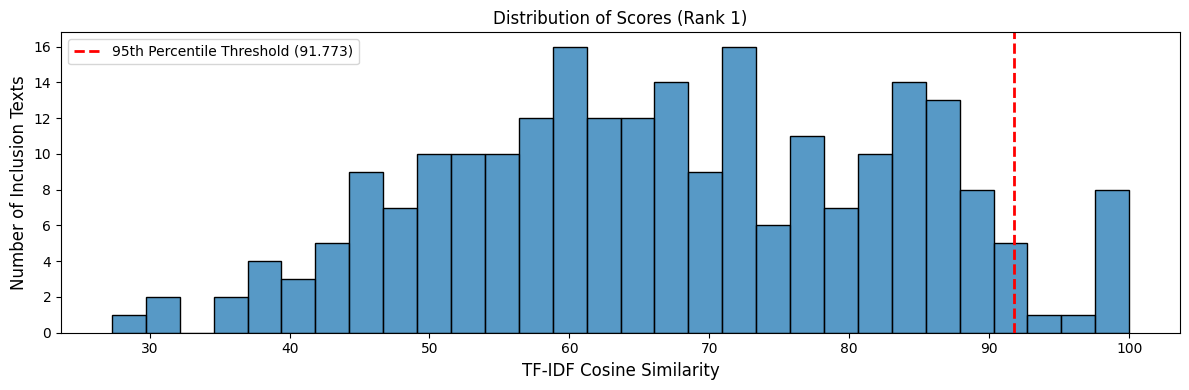

In [11]:
rank1_df = top5_df.query('rank == 1')
P = 95 # Increase for higher confidence, and vice versa.
threshold = np.percentile(rank1_df['score'], P)

fig, ax = plt.subplots(figsize=(12, 4))
sns.histplot(
    data=rank1_df, 
    x="score", 
    bins=30,
    ax=ax
)

ax.axvline(x=threshold, color='red', linestyle='--', linewidth=2, label=f'{P}th Percentile Threshold ({threshold:.3f})')

ax.set_title("Distribution of Scores (Rank 1)", fontsize=12)
ax.set_xlabel("TF-IDF Cosine Similarity", fontsize=12)
ax.set_ylabel("Number of Inclusion Texts", fontsize=12)
ax.legend()

plt.tight_layout()
plt.show()

In [12]:
cutoff_res = top5_df.query(f'score >= {threshold}')

mapped_count = len(cutoff_res['include'].unique())
total_count = len(queries)
print(f"Successfully Mapped: {mapped_count / total_count:.2%} ({mapped_count} out of {total_count} inclusions)")

cutoff_res = cutoff_res.merge(main, left_on='matched_title', right_on='title', how='left')
cutoff_res = cutoff_res.drop(columns = ["title"])
cutoff_res

Successfully Mapped: 5.04% (12 out of 238 inclusions)


,include,rank,matched_title,score,Code
0,operations on: pineal gland,1,operations on: pineal gland,100.000000,"0717, 0751-0759"
1,Directional atherectomy,1,Directional atherectomy,100.000000,1753
2,Directional atherectomy,1,Directional atherectomy,100.000000,1754
3,Directional atherectomy,1,Directional atherectomy,100.000000,1755
4,Excimer laser atherectomy,1,Excimer laser atherectomy,100.000000,1753
5,Excimer laser atherectomy,1,Excimer laser atherectomy,100.000000,1754
6,Excimer laser atherectomy,1,Excimer laser atherectomy,100.000000,1755
7,Rotational atherectomy,1,Rotational atherectomy,100.000000,1753
8,Rotational atherectomy,1,Rotational atherectomy,100.000000,1754
9,Rotational atherectomy,1,Rotational atherectomy,100.000000,1755


In [13]:
# Margin map + P95 threshold map
inc_map_all = pd.concat([cutoff_res, safe_matches])
inc_map = inc_map_all[["Code", "include"]].drop_duplicates()
print(f"Successfully Mapped: {len(inc_map['include'].unique()) / len(queries):.2%} ({len(inc_map['include'].unique())} out of {len(queries)} inclusions)")
inc_map

Successfully Mapped: 17.65% (42 out of 238 inclusions)


,Code,include
0,"0717, 0751-0759",operations on: pineal gland
1,1753,Directional atherectomy
2,1754,Directional atherectomy
3,1755,Directional atherectomy
4,1753,Excimer laser atherectomy
5,1754,Excimer laser atherectomy
6,1755,Excimer laser atherectomy
7,1753,Rotational atherectomy
8,1754,Rotational atherectomy
9,1755,Rotational atherectomy


In [14]:
icd9_inc = icd9[["Code", "title", "include"]].dropna()
icd9_inc = icd9_inc.explode("include")
icd9_inc = icd9_inc.merge(inc_map, on='include', how='inner', suffixes=('','_include'))

# Exclude map include to self
icd9_inc = icd9_inc.query("Code != Code_include")
icd9_inc = icd9_inc.groupby(by=['Code', 'title', 'include'],as_index=False).agg(list)
icd9_inc

,Code,title,include,Code_include
0,0064,Percutaneous insertion of other extracranial a...,Vertebral stent,[0061]
1,07,Operations on other endocrine glands,operations on: pineal gland,"[0717, 0751-0759]"
2,07,Operations on other endocrine glands,operations on: thymus,[079]
3,1756,Atherectomy of other non-coronary vessel(s),Directional atherectomy,"[1753, 1754, 1755]"
4,1756,Atherectomy of other non-coronary vessel(s),Excimer laser atherectomy,"[1753, 1754, 1755]"
5,1756,Atherectomy of other non-coronary vessel(s),Rotational atherectomy,"[1753, 1754, 1755]"
6,2096,Implantation or replacement of cochlear prosth...,mastoidectomy,"[204, 2049]"
7,2097,Implantation or replacement of cochlear prosth...,mastoidectomy,"[204, 2049]"
8,2098,Implantation or replacement of cochlear prosth...,mastoidectomy,"[204, 2049]"
9,3768,Insertion of percutaneous external heart assis...,Extrinsic heart assist device,[9744]


In [ ]:
def expand_icd9(interval_string : str, valid_codes : list[str]):
    """
    Expands ICD-9 strings into individual codes, 
    filtering against a list of known valid codes.
    """
    valid_set = set(valid_codes)
    expanded_codes = []

    parts = [p.strip() for p in interval_string.split(',')]

    for part in parts:
        if '-' in part:
            # Step 1: Split the range (e.g., "0751-0759")
            start, end = part.split('-')
            start = start.strip()
            end = end.strip()
            

            # Step 3: Track the length to maintain leading zeros (e.g., 4 characters)
            num_length = len(start)

            # Step 4: Generate the sequence
            for num in range(int(start), int(end) + 1):
                generated_code = str(num).zfill(num_length)
                
                # Step 5: Only add it if it actually exists in your data
                if generated_code in valid_set:
                    expanded_codes.append(generated_code)

        else:
            base_code = part.strip()
            
            # Loop through the valid set to find the exact code AND any detailed sub-codes
            for valid_code in valid_set:
                if valid_code.startswith(base_code):
                    expanded_codes.append(valid_code)

    return sorted(expanded_codes)

print(expand_icd9('0717, 0751-0759', icd9['Code'].tolist()))
print(expand_icd9('8130- 8139', icd9['Code'].tolist()))
print(expand_icd9('204', icd9['Code'].tolist()))

['0717', '0751', '0752', '0753', '0754', '0759']
['8130', '8131', '8132', '8133', '8134', '8135', '8136', '8137', '8138', '8139']
['204', '2041', '2042', '2049']


In [16]:
valid_set = icd9['Code'].tolist()
icd9_inc['Code_include_expand'] = icd9_inc['Code_include'].apply(
    lambda x: sorted(list(set(
        expanded_code 
        for c in x 
        for expanded_code in expand_icd9(c, valid_set)
    ))) if isinstance(x, list) else []
)
icd9_inc

,Code,title,include,Code_include,Code_include_expand
0,0064,Percutaneous insertion of other extracranial a...,Vertebral stent,[0061],[0061]
1,07,Operations on other endocrine glands,operations on: pineal gland,"[0717, 0751-0759]","[0717, 0751, 0752, 0753, 0754, 0759]"
2,07,Operations on other endocrine glands,operations on: thymus,[079],"[079, 0791, 0792, 0793, 0794, 0795, 0798, 0799]"
3,1756,Atherectomy of other non-coronary vessel(s),Directional atherectomy,"[1753, 1754, 1755]","[1753, 1754, 1755]"
4,1756,Atherectomy of other non-coronary vessel(s),Excimer laser atherectomy,"[1753, 1754, 1755]","[1753, 1754, 1755]"
5,1756,Atherectomy of other non-coronary vessel(s),Rotational atherectomy,"[1753, 1754, 1755]","[1753, 1754, 1755]"
6,2096,Implantation or replacement of cochlear prosth...,mastoidectomy,"[204, 2049]","[204, 2041, 2042, 2049]"
7,2097,Implantation or replacement of cochlear prosth...,mastoidectomy,"[204, 2049]","[204, 2041, 2042, 2049]"
8,2098,Implantation or replacement of cochlear prosth...,mastoidectomy,"[204, 2049]","[204, 2041, 2042, 2049]"
9,3768,Insertion of percutaneous external heart assis...,Extrinsic heart assist device,[9744],[9744]


In [17]:
# Export summary table
# 1. Prepare Sheet 1 Data
icd9_inc_export = icd9_inc.copy()
list_val_cols = ["Code_include", "Code_include_expand"]

for c in list_val_cols:
    icd9_inc_export[c] = icd9_inc_export[c].apply(
        lambda x: ', '.join([str(i) for i in x]) if isinstance(x, list) else x
    )
display(icd9_inc_export)
    
# 2. Prepare Sheet 2 All mapping score
top5_df_res = top5_df.merge(
    main, left_on='matched_title', right_on='title', how='left'
).drop(columns=['title'])
top5_df_res = top5_df_res.groupby(by = top5_df_res.columns[:-1].tolist(), as_index=False).agg(list)
ground_truth = (
    inc_map_all[['include', 'matched_title']]
    .drop_duplicates())

top5_df_res = top5_df_res.merge(ground_truth, on=['include', 'matched_title'], how='left', indicator=True)
top5_df_res['IS_MAP'] = top5_df_res['_merge'] == "both"
top5_df_res = top5_df_res.drop(columns = '_merge')
top5_df_res['Code'] = top5_df_res['Code'].apply(
        lambda x: ', '.join([str(i) for i in x]) if isinstance(x, list) else x
    )
display(top5_df_res)


# 2. Export to Excel
output_filename = "../result/icd9_inclusion_mapping_summary.xlsx"
print(f"Exporting data to {output_filename}...")

with pd.ExcelWriter(output_filename, engine='xlsxwriter') as writer:
    icd9_inc_export.to_excel(writer, sheet_name='Inclusion Mapping', index=False)
    top5_df_res.to_excel(writer, sheet_name='Top 5 Matches', index=False)

,Code,title,include,Code_include,Code_include_expand
0,0064,Percutaneous insertion of other extracranial a...,Vertebral stent,0061,0061
1,07,Operations on other endocrine glands,operations on: pineal gland,"0717, 0751-0759","0717, 0751, 0752, 0753, 0754, 0759"
2,07,Operations on other endocrine glands,operations on: thymus,079,"079, 0791, 0792, 0793, 0794, 0795, 0798, 0799"
3,1756,Atherectomy of other non-coronary vessel(s),Directional atherectomy,"1753, 1754, 1755","1753, 1754, 1755"
4,1756,Atherectomy of other non-coronary vessel(s),Excimer laser atherectomy,"1753, 1754, 1755","1753, 1754, 1755"
5,1756,Atherectomy of other non-coronary vessel(s),Rotational atherectomy,"1753, 1754, 1755","1753, 1754, 1755"
6,2096,Implantation or replacement of cochlear prosth...,mastoidectomy,"204, 2049","204, 2041, 2042, 2049"
7,2097,Implantation or replacement of cochlear prosth...,mastoidectomy,"204, 2049","204, 2041, 2042, 2049"
8,2098,Implantation or replacement of cochlear prosth...,mastoidectomy,"204, 2049","204, 2041, 2042, 2049"
9,3768,Insertion of percutaneous external heart assis...,Extrinsic heart assist device,9744,9744


,include,rank,matched_title,score,Code,IS_MAP
0,Atherectomy of other non-coronary vessel(s) Th...,1,Atherectomy of other non-coronary vessel(s),90.068478,1756,False
1,Atherectomy of other non-coronary vessel(s) Th...,2,atherectomy of other non-coronary vessel(s),90.068478,1756,False
2,Atherectomy of other non-coronary vessel(s) Th...,3,atherectomy of other non-coronary vessels(s),75.380002,1756,False
3,Atherectomy of other non-coronary vessel(s) Th...,4,Angioplasty of other non-coronary vessel(s),73.096378,3950,False
4,Atherectomy of other non-coronary vessel(s) Th...,5,angioplasty of other non-coronary vessel(s),73.096378,3950,False
...,...,...,...,...,...,...
1185,with synchronous colostomy,1,any synchronous colostomy,84.642592,4610-4613,False
1186,with synchronous colostomy,2,any synchronous: colostomy,76.746334,4612-4613,False
1187,with synchronous colostomy,3,Anterior resection of rectum with synchronous ...,74.859585,4862,False
1188,with synchronous colostomy,4,Colostomy that with synchronous anterior recta...,73.647839,4862,False


Exporting data to ../result/icd9_inclusion_mapping_summary.xlsx...


In [18]:
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.utils import get_column_letter

# 1. Load your existing Excel file
file_path = output_filename
wb = load_workbook(file_path)

print(f"Applying formatting to {file_path}...")

# 2. Loop through all the sheets in your workbook
for sheet_name in wb.sheetnames:
    ws = wb[sheet_name]

    # --- BEATIFICATION STEP A: Auto-fit Column Widths ---
    for col in ws.columns:
        max_length = 0
        column = col[0].column_letter # Gets the letter (A, B, C...)
        
        # Find the longest string of text in the entire column
        for cell in col:
            try:
                if len(str(cell.value)) > max_length:
                    max_length = len(str(cell.value))
            except:
                pass
        
        # Add a little padding (+2) and set the new width. 
        # (We cap it at 75 so extremely long inclusion texts don't stretch the screen too far)
        adjusted_width = min(max_length + 2, 75) 
        ws.column_dimensions[column].width = adjusted_width

    # --- BEATIFICATION STEP B: Style the Header Row ---
    # Create a light gray fill and a bold font
    header_fill = PatternFill(start_color="E0E0E0", end_color="E0E0E0", fill_type="solid")
    header_font = Font(bold=True, color="000000")

    # Apply the styling to every cell in the first row
    for cell in ws[1]: 
        cell.font = header_font
        cell.fill = header_fill
        # Center the text and wrap it if it gets too long
        cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

    # --- BEATIFICATION STEP C: Highlight IS_MAP = True ---
    # 1. Find which column has the header "IS_MAP"
    is_map_col_idx = None
    for cell in ws[1]:
        if cell.value == "IS_MAP":
            is_map_col_idx = cell.column
            break
            
    # 2. If the column exists in this specific sheet, apply the color
    if is_map_col_idx is not None:
        # Define a nice, readable light green fill
        green_fill = PatternFill(start_color="C6EFCE", end_color="C6EFCE", fill_type="solid")
        
        # Loop through rows in that column (starting at row 2 to skip the header)
        for row in range(2, ws.max_row + 1):
            cell = ws.cell(row=row, column=is_map_col_idx)
            
            # Check if the cell is boolean True or the text "True"
            if cell.value is True or str(cell.value).strip().upper() == "TRUE":
                cell.fill = green_fill

# 3. Save the changes back to the file
wb.save(file_path)
print("Excel file successfully beautified!")

Applying formatting to ../result/icd9_inclusion_mapping_summary.xlsx...
Excel file successfully beautified!
